# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Albert Eli Kwasi Andzi-Quainoo
**Student ID:** 47762028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


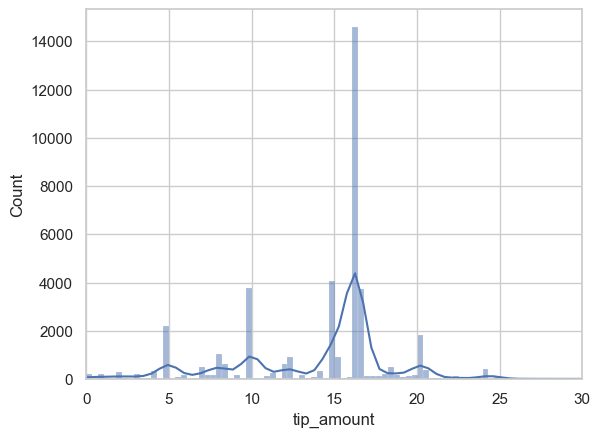

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`- DONE
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it - DONE
# - taxi.shape, taxi.head(), taxi.info()
taxi.shape, taxi.head(), taxi.info()

# - taxi.describe()
taxi.describe()

# - count missing values per column: taxi.isna().sum()
taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount` - DONE
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(data=taxi, x="tip_amount", kde=True)
plt.xlim(0,30)
plt.show()

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** 
The taxi dataset has [41202] rows and [13] columns. The `tip_amount` distribution is right-skewed: most trips have small tips, while a small number have very large tips/outliers. I also checked for invalid values such as zero-distance trips, non-positive fares, and negative tips. This influenced my preprocessing because I removed invalid rows before feature engineering, especially since `tip_rate_proxy = fare_amount / trip_distance` would fail or create infinity when trip distance is zero.




### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [3]:
from sklearn.preprocessing import StandardScaler 

# TODO: Handle missing / invalid rows - DONE
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi_cleaned = taxi[taxi['trip_distance'].notna() & taxi['fare_amount'].notna() & (taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0) & (taxi['tip_amount'] >= 0)]


# TODO: Feature engineering — create at least ONE new, justified feature, for example: - DONE
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge

# Creating a list of the leaked features 
leaked_features = ['tip_amount']

# Creating the new justified features
taxi_cleaned['tip_rate_proxy'] = taxi_cleaned['fare_amount'] / taxi_cleaned['trip_distance']
taxi_cleaned['total_surcharges'] = taxi_cleaned['mta_tax'] + taxi_cleaned['tolls_amount'] + taxi_cleaned['improvement_surcharge']

# Dropping leaked column 
taxi_cleaned_leaked_dropped = taxi_cleaned.drop(columns=leaked_features)


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type, - DONE
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_columns = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag'] # Categorical columns
numeric_columns = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_rate_proxy','total_surcharges'] # Numerical columns

# One-hot encoding categorical columns
taxi_cleaned_leaked_dropped = pd.get_dummies(
    taxi_cleaned_leaked_dropped,
    columns=categorical_columns,
    drop_first=True
)



# TODO: Scale the numeric features. - DONE



**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**
1. I removed invalid rows where `trip_distance <= 0`, `fare_amount <= 0`, or `tip_amount < 0`. I did this because zero distance would create infinite values when calculating the fare-per-mile.

2. I engineered `tip_rate_proxy = fare_amount / trip_distance` and `total_surcharges`. This is because it combines extra charges into one feature. These charges affect the total cost of the ride and may influence how much a passenger tips. Instead of having them as separate small components, the feature summarises the extra non-fare costs.

3. For scaling, I used StandardScaler for numeric features so that numeric features with larger values would not dominate. 


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [4]:
from sklearn.model_selection import train_test_split

# TODO: Separate features (X) and target (y = tip_amount) - DONE
X = taxi_cleaned_leaked_dropped
y = taxi_cleaned['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20). - DONE
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# Spliting 20% for the final test set 
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,y, test_size=0.20, random_state=RANDOM_STATE
)

# Splitting the rest
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test. - DONE
#   (Explain in the reasoning box why scaling must be fit on train only.)

# Instantiating the scalar
scaler = StandardScaler()

# Fitting the training data and trasnforming
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])

# ONLY transforming the validation data (No fitting here)
X_val_scaled = scaler.transform(X_val[numeric_columns])

# ONLY transforming the test data (No fitting here)
X_test_scaled = scaler.transform(X_test[numeric_columns])


# Making copies of the scaled numbers and putting them back into the DataFrame (Keeping the categoricals)
X_train_ready = X_train.copy()
X_val_ready = X_val.copy()
X_test_ready = X_test.copy()

X_train_ready[numeric_columns] = X_train_scaled
X_val_ready[numeric_columns] = X_val_scaled
X_test_ready[numeric_columns] = X_test_scaled


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:**
- I used a 60/20/20 train/validation/test split. 

- A separate validation set is useful to compare models and tune the decisions of them, while the test set is reserved for final evaluation.

- The scaler must be fit only on training data to avoid leaking validation/test distribution information into training. 



### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

Train RMSE: 4.804452555330034
Validation RMSE: 5.037135953076983
Test RMSE: 5.0131789527740915
Train R²: 0.051327956775104155
Validation R²: 0.04863478237663155
Test R²: 0.051062049212356686


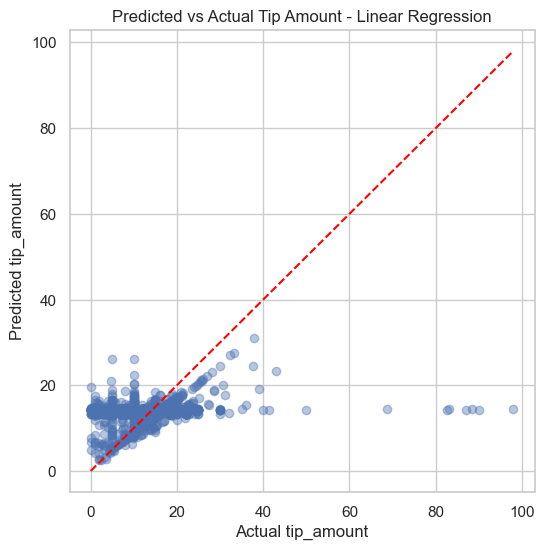

RF Train RMSE: 4.603777736829787
RF Validation RMSE: 5.06598837234947
RF Test RMSE: 5.033784226795396
RF Train R²: 0.12892212867281283
RF Validation R²: 0.03770484041503108
RF Test R²: 0.04324532831467709


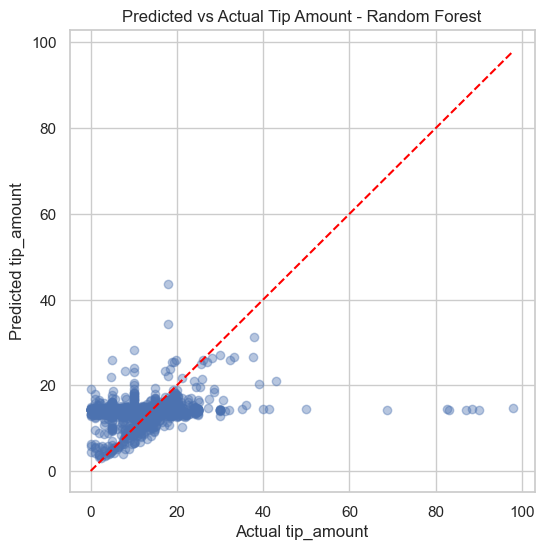

In [5]:
# TODO: Import, initialise, and train a regression model. - DONE 
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# TODO: Predict on train, validation, and test sets. - DONE

#Training
model = LinearRegression()
model.fit(X_train_ready, y_train)


# Predicting
y_train_pred = model.predict(X_train_ready)
y_val_pred = model.predict(X_val_ready)
y_test_pred = model.predict(X_test_ready)



# TODO: Report RMSE and R^2 for ALL THREE sets. - DONE
# RMSE
train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

# R^2
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Results
print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Test RMSE:", test_rmse)

print("Train R²:", train_r2)
print("Validation R²:", val_r2)
print("Test R²:", test_r2)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line). - DONE
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred,alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual tip_amount")
plt.ylabel("Predicted tip_amount")
plt.title("Predicted vs Actual Tip Amount - Linear Regression")
plt.show()

# Using Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train_ready, y_train)

rf_train_pred = rf_model.predict(X_train_ready)
rf_val_pred = rf_model.predict(X_val_ready)
rf_test_pred = rf_model.predict(X_test_ready)


# RMSE (Random Forest)
rf_train_rmse = mean_squared_error(y_train, rf_train_pred) ** 0.5
rf_val_rmse = mean_squared_error(y_val, rf_val_pred) ** 0.5
rf_test_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5

# R^2 (Random Forest)
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_test_r2 = r2_score(y_test,rf_test_pred)


# Results
print("RF Train RMSE:", rf_train_rmse)
print("RF Validation RMSE:", rf_val_rmse)
print("RF Test RMSE:", rf_test_rmse)

print("RF Train R²:", rf_train_r2)
print("RF Validation R²:", rf_val_r2)
print("RF Test R²:", rf_test_r2)

# Random Forest plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_test_pred,alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual tip_amount")
plt.ylabel("Predicted tip_amount")
plt.title("Predicted vs Actual Tip Amount - Random Forest")
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**
1. Linear Regression performed best on the validation RMSE since lower RMSE is better. 
Linear validation RMSE ≈ 5.04
Random Forest validation RMSE ≈ 5.07

2. Linear Regression:
Train RMSE ≈ 4.80, Val RMSE ≈ 5.04, Test RMSE ≈ 5.01
Train R² ≈ 0.051, Val R² ≈ 0.049, Test R² ≈ 0.051

    Random Forest:
    Train RMSE ≈ 4.60, Val RMSE ≈ 5.07, Test RMSE ≈ 5.03
    Train R² ≈ 0.129, Val R² ≈ 0.038, Test R² ≈ 0.043

    Linear Regression underfits because the R^2 is very low across all splits. Random Forest improves training performance but not validation/test, pointing to mild overfitting and weak generalisation.


3. To reduce overfitting, I would constrain the Random Forest model by lowering `max_depth`, increasing `min_samples_leaf`, or reducing model complexity. I would also compare models using the validation set and avoid choosing a model only because it performs well on training data. Since the Random Forest improved train R² but had worse validation/test R², stronger regularization or going for a simpler model would be more appropriate.

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Text(0.5, 1.0, 'Distribution of NObeyesdad')

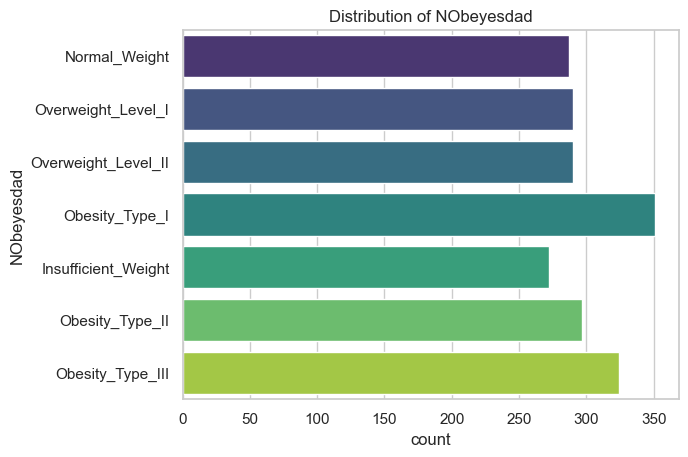

In [6]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity` - DONE
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values. - DONE
obesity.shape, obesity.head(), obesity.info(), obesity.describe(), obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad` - DONE
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
sns.countplot(data=obesity, y="NObeyesdad", hue="NObeyesdad", palette="viridis", legend=False)
plt.title("Distribution of NObeyesdad")


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**
- There are `2111` rows with `16` input features, plus the target column NObeyesdad.

- The numeric columns are Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad.

- The target is not balanced across the 7 classes but they are reasonably represented. Class balance matters because if one class is much larger than the others, a classifier can get high accuracy by mostly predicting the majority class while performing poorly on minority classes. This is why macro-F1 and stratified splitting are useful.



### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [7]:
# TODO: Encode categorical columns. - DONE
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

from sklearn.preprocessing import LabelEncoder

# Making a copy
obesity_clean = obesity.copy()

# For binary columns
obesity_clean["family_history_with_overweight"] = obesity_clean["family_history_with_overweight"].map({
    "yes": 1,
    "no" : 0
})

obesity_clean["FAVC"] = obesity_clean["FAVC"].map({
    "yes":1,
    "no":0
})

obesity_clean["SMOKE"] = obesity_clean["SMOKE"].map({
    "yes":1,
    "no":0
})

obesity_clean["SCC"] = obesity_clean["SCC"].map({
    "yes":1,
    "no":0
})

#Ordinal-ish columns

# Making an ordinal map
ordinal_map = {
    "no":0,
    "Sometimes":1,
    "Frequently":2,
    "Always":3
}


# Mapping the columns in order (with the ordinal map)
obesity_clean["CAEC"] = obesity_clean["CAEC"].map(ordinal_map)
obesity_clean["CALC"] = obesity_clean["CALC"].map(ordinal_map)

# Nominal columns

obesity_clean["Gender"] = obesity_clean["Gender"].map({
    "Female" : 0,
    "Male" : 1
})


obesity_encoded = pd.get_dummies(
    obesity_clean,
    columns=["MTRANS"],
    drop_first=True
)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2. - DONE
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# Creating the domain feature (BMI)
obesity_encoded["BMI"] = obesity_encoded["Weight"] / (obesity_encoded["Height"] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels - DONE

label_encoder = LabelEncoder() # Initalising the encoder 

# Encoding the target column
obesity_encoded["NObeyesdad_encoded"] = label_encoder.fit_transform(
    obesity_encoded["NObeyesdad"]
)


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3). - DONE



**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 
1. 
- Binary yes/no columns were mapped to 0/1.
- Gender was mapped to 0/1.
- CAEC and CALC were treated as ordinal-ish and mapped in order: no, Sometimes, Frequently, Always.
- MTRANS was nominal, so I used one-hot encoding.

2. I did engineer BMI as Weight / Height². BMI is meaningful because obesity level relates to height and weight, but it may make the task easier because it is closely related to the target.

3. I used StandardScaler on the continuous numeric features after the train/validation/test split. I fit the scaler only on the training set, then transformed the validation and test sets using the same scaler. StandardScaler is appropriate because features such as Age, Height, Weight, CH2O, FAF, TUE, and BMI are on different scales, and scaling helps models like Logistic Regression treat them more comparably. I did not scale the target labels.
Also, The one-hot encoded categorical columns were already 0/1, so I left them unchanged.

### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [8]:
# TODO: Separate X (features) and y (encoded NObeyesdad). - DONE
X = obesity_encoded.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y = obesity_encoded["NObeyesdad_encoded"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes. - DONE
#   Use random_state=RANDOM_STATE.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)


# TODO: Fit the scaler on the training set only, then transform train / val / test. - DONE

numeric_columns = [
    "Age", "Height", "Weight", "FCVC", "NCP",
    "CH2O", "FAF", "TUE", "BMI"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val_scaled[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**
- The 60/20/20 train/validation/test split was also used here. 

- I used `stratify=y` to preserve class proportionality across all splits.

- Without stratification, some classes might be underrepresented or missing in validation/test, making evaluation unreliable.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Train accuracy: 0.9281200631911533
Validation accuracy: 0.8838862559241706
Test accuracy: 0.900709219858156
Train macro-F1: 0.9257656611381293
Validation macro-F1: 0.8778900914817417
Test macro-F1: 0.8972283068611041


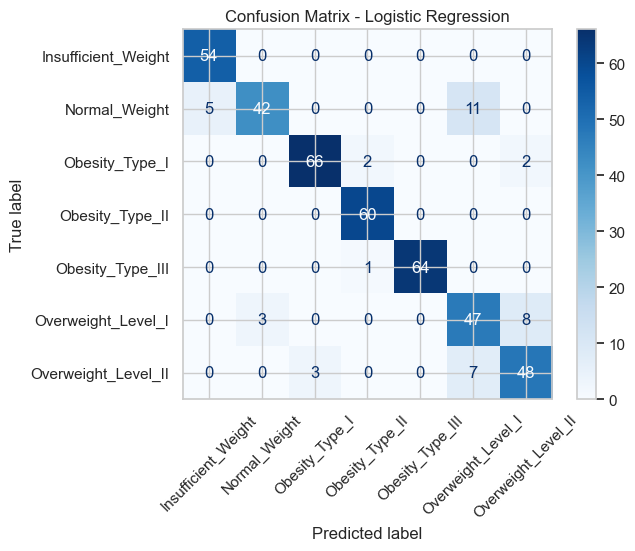

In [9]:
# TODO: Import, initialise, and train a classifier - DONE
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Confusion Matrix display import
from sklearn.metrics import ConfusionMatrixDisplay


clf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

clf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test. - DONE
y_train_pred = clf.predict(X_train_scaled)
y_val_pred = clf.predict(X_val_scaled)
y_test_pred = clf.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets - DONE

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# macro-F1
train_macro_f1 = f1_score(y_train, y_train_pred, average="macro")
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

# Displaying results 
print("Train accuracy:", train_accuracy)
print("Validation accuracy:", val_accuracy)
print("Test accuracy:", test_accuracy)

print("Train macro-F1:", train_macro_f1)
print("Validation macro-F1:", val_macro_f1)
print("Test macro-F1:", test_macro_f1)


# TODO: Show a confusion matrix for the test set - DONE

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**
1. I chose Logistic Regression because it is a simple and interpretable baseline classifier for multi-class classification. It works well with numeric, scaled features and gives a good starting point before trying more complex models.

2. The model performed well overall. The train accuracy was about 0.928 and train macro-F1 was about 0.926. The validation accuracy was about 0.884 and validation macro-F1 was about 0.878. The test accuracy was about 0.901 and test macro-F1 was about 0.897. Since the train scores are only moderately higher than validation/test, the model shows mild overfitting but still generalizes well.

3. From the confusion matrix, the hardest obesity levels to tell apart were neighboring categories, especially Normal_Weight vs Overweight_Level_I and Overweight_Level_I vs Overweight_Level_II. This makes sense because adjacent weight categories are close in body measurements and lifestyle features, so their feature values can overlap.



---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


k=2, inertia=18034.92, silhouette=0.162
k=3, inertia=16222.14, silhouette=0.161
k=4, inertia=14765.56, silhouette=0.174
k=5, inertia=13661.89, silhouette=0.161
k=6, inertia=12781.51, silhouette=0.159
k=7, inertia=12229.94, silhouette=0.159
k=8, inertia=11714.62, silhouette=0.156
k=9, inertia=11322.96, silhouette=0.156
k=10, inertia=10954.41, silhouette=0.166


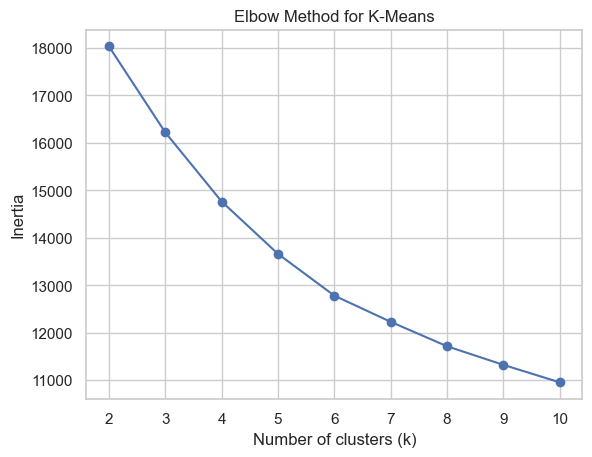

Original shape: (2111, 20)
Reduced shape: (2111, 2)


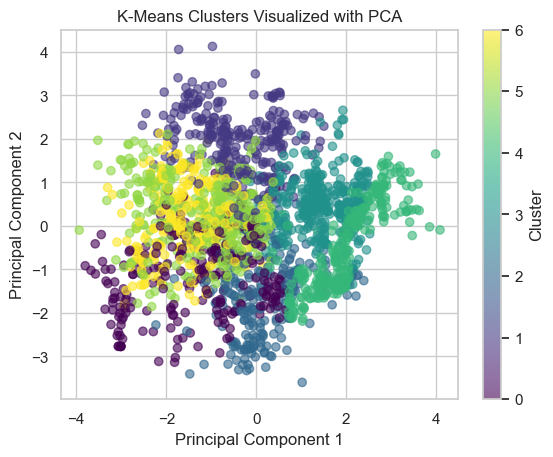

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering. - DONE
X = obesity_encoded.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])

# Making a scaled version that uses the full X (minus the target)
obesity_scaled = X.copy()
obesity_scaled[numeric_columns] = scaler.fit_transform(X[numeric_columns])


# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score). - DONE
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# Storing inertia and silhouette values (for each k)
inertias = []
silhouettes = []

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels. - DONE

# Looping k from 2 to 10
for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10) # instantiate k-means
    labels = model.fit_predict(obesity_scaled) # Generating labels
    inertias.append(model.inertia_) # Capture recorded inertia_
    silhouettes.append(silhouette_score(obesity_scaled, labels)) # Computing silhouette score and storing

    print(f"k={k}, inertia={model.inertia_:.2f}, silhouette={silhouettes[-1]:.3f}") # Displaying results


# Inertia v k plot
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


# Fitting final K-Means model with chosen k
chosen_k = 7

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)

# Generating labels with chosen k
cluster_labels = kmeans.fit_predict(obesity_scaled)


# TODO: Visualise the clusters in 2D. - DONE
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA

# Using PCA

# Instantiating PCA and defing target dimensions to 2
pca = PCA(n_components=2)

# Fitting the model and applying dimensionality reduction
obesity_PCA = pca.fit_transform(obesity_scaled)

# Converting to dataframe
df_pca = pd.DataFrame(data=obesity_PCA, columns=['Principal Component 1', 'Principal Component 2'])

# Comparison between original shape and reduced shape (expected features/columns = 2)
print(f"Original shape: {obesity_scaled.shape}")
print(f"Reduced shape: {df_pca.shape}")

# Visualising the clusters
plt.scatter(
    df_pca["Principal Component 1"],
    df_pca["Principal Component 2"],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

In [11]:
# TODO: How well do the clusters line up with the TRUE obesity levels? 
#   Build a crosstab of cluster label vs the real NObeyesdad category: - DONE

cluster_table = pd.crosstab(
    pd.Series(cluster_labels, name="Cluster"),
    obesity_encoded["NObeyesdad"]
)

cluster_table
#   Do some clusters map cleanly onto specific obesity levels?


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,41,50,55,28,0,67,34
1,71,57,42,0,0,61,47
2,1,11,68,45,0,46,66
3,0,2,110,210,0,9,41
4,0,0,1,13,324,0,1
5,56,83,63,0,0,79,69
6,103,84,12,1,0,28,32


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:**
1. I chose k = 7 because the real dataset has 7 obesity categories, so it gives a direct comparison between unsupervised clusters and the true labels. The elbow plot showed inertia decreasing as k increased, but there was no very sharp elbow. The silhouette scores were also low overall, with k = 4 slightly higher, but k = 7 was still useful for comparing against the 7 known classes.

2. The clusters partly resemble the real obesity levels, but not perfectly. Cluster 4 maps very clearly to Obesity_Type_III, with 324 examples from that class and almost no other labels. Cluster 3 mostly captures Obesity_Type_II and Obesity_Type_I. Cluster 6 contains many Insufficient_Weight and Normal_Weight examples. However, several clusters are mixed across Normal_Weight, Overweight, and Obesity_Type_I/II, so K-Means does not cleanly recover every true class.

3. In a real public-health setting, these clusters could be useful for discovering groups of people with similar body/lifestyle profiles when labels are expensive to collect. For example, one cluster might identify a high-risk group that should receive earlier screening or intervention. However, the clusters should not replace true medical labels because some clusters mix multiple obesity levels.

---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
  
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
   
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 
1. - The classifier learned to predict known obesity levels using examples and target labels.
   - K-Means found groups based only feature similarity
   - The classifier produced much better label-specific performance, while K-Means showed rough natural groupings but did not perfectly match the classes.

 2. - Regression predicted a continuous value, tip_amount, so I used RMSE and R².
    - Classification predicted categories, so I used accuracy, macro-F1, and a confusion matrix.
    - Regression errors measure distance from the true number, while classification errors measure whether the predicted class is correct.

 3. - The biggest train-vs-test gap appeared in the taxi Random Forest regression.
    - Random Forest had better train R² than Linear Regression but worse validation/test R².
    - That suggests it learned some training-specific patterns without improving generalization.





---
### Submission checklist

- [x] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [x] Every **Student Reasoning** box is filled in with full sentences.
- [x] Plots are visible in the saved notebook.
- [x] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [x] Repository link submitted to the course portal.
- [x] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
